In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

In [2]:
class MOLR:
    def __init__(self,p,r):
        """
        p: prediction horizon
        r: memory of model (sample amount in asingle row of X)
        m: feature amount
        n: dataset length
        """
        self.p = p
        self.r = r
        self.n = None
        self.m = None
        self.W = None

    def _show(lst):
        for row in lst:
            print(row)

    def _gradient(self,Xt,Y):
        return (2 / (self.n-self.p-self.r+1)) * Xt.T @ (Xt @ self.W - Y)

    def _loss(self,Xt,Y):
        diff = Xt @ self.W - Y
        return (1 / (self.n-self.p-self.r+1)) * np.trace(diff.T @ diff)

    def _rel_cond(self,old_loss,loss,epsilon):
        return abs((loss-old_loss)/old_loss)>epsilon

    def fit(self,df,epsilon=0.01,alpha=0.01,inform=0):
        """
        epsilon: relative error threshold
        alpha: step size
        inform: 0(least informed),1,2,3(most informed)

        returns loss history
        """
        print("Model training started...")

        self.n, self.m = df.shape

        # create X
        X = np.array([df[k : k + self.r] for k in range(self.n - self.p - self.r + 1)])
        X = X.reshape(X.shape[0], -1)

        # create Y
        Y = np.array([df[k + self.r : k + self.r + self.p] for k in range(self.n - self.p - self.r + 1)])
        Y = Y.reshape(Y.shape[0], -1)

        # create Xt
        X_flattened = X.reshape(X.shape[0], -1)
        ones_column = np.ones((X_flattened.shape[0], 1))
        Xt = np.column_stack((ones_column, X_flattened))

        # create W
        self.W = np.zeros((self.r * self.m + 1, self.p * self.m))

        if inform==3:
            print("df shape:", df.shape)
            print("X shape:", X.shape)
            print("Y shape:", Y.shape)
            print("Xt shape:", Xt.shape)
            print("W shape:", self.W.shape)
            print("\n-- Weights First --")
            self._show(self.W)

        iter_num = 0
        loss = self._loss(Xt, Y)
        losses = [loss]

        while iter_num == 0 or self._rel_cond(old_loss, loss, epsilon):
            old_loss = loss
            self.W = self.W - alpha * self._gradient(Xt, Y)
            loss = self._loss(Xt, Y)

            if inform == 2:
                print(f"iter {iter_num}: loss: {loss}, old loss: {old_loss}")
            elif inform == 1:
                print(f"iter {iter_num}: loss: {loss}")

            iter_num += 1
            losses.append(loss)

        if inform == 3:
            print("\n-- Weights Last --")
            self._show(self.W)

        print("Model training finished.")
        return losses

    def predict(self, X):
        """x: 1, x1, x2, ... , xrm"""
        x = X[-self.r:].flatten()
        x = np.insert(x, 0, 1)
        preds = x @ self.W
        answers = preds.reshape(self.p, self.m)

        return answers

In [3]:
def generate_synthetic_ts(n, m):
    t = np.arange(n)
    synthetic_data = np.zeros((n, m))

    for col in range(m):
        trend_slope = np.random.uniform(-0.5, 0.5)
        seasonal_amplitude = np.random.uniform(5, 15)
        period = np.random.randint(10, 30)
        noise_level = np.random.uniform(1, 3)

        phase_shift = np.random.uniform(0, 2 * np.pi)

        trend = trend_slope * t
        seasonality = seasonal_amplitude * np.sin((2 * np.pi * t / period) + phase_shift)
        noise = np.random.normal(0, noise_level, n)

        f = trend + seasonality + noise

        synthetic_data[:, col] = f

    return synthetic_data

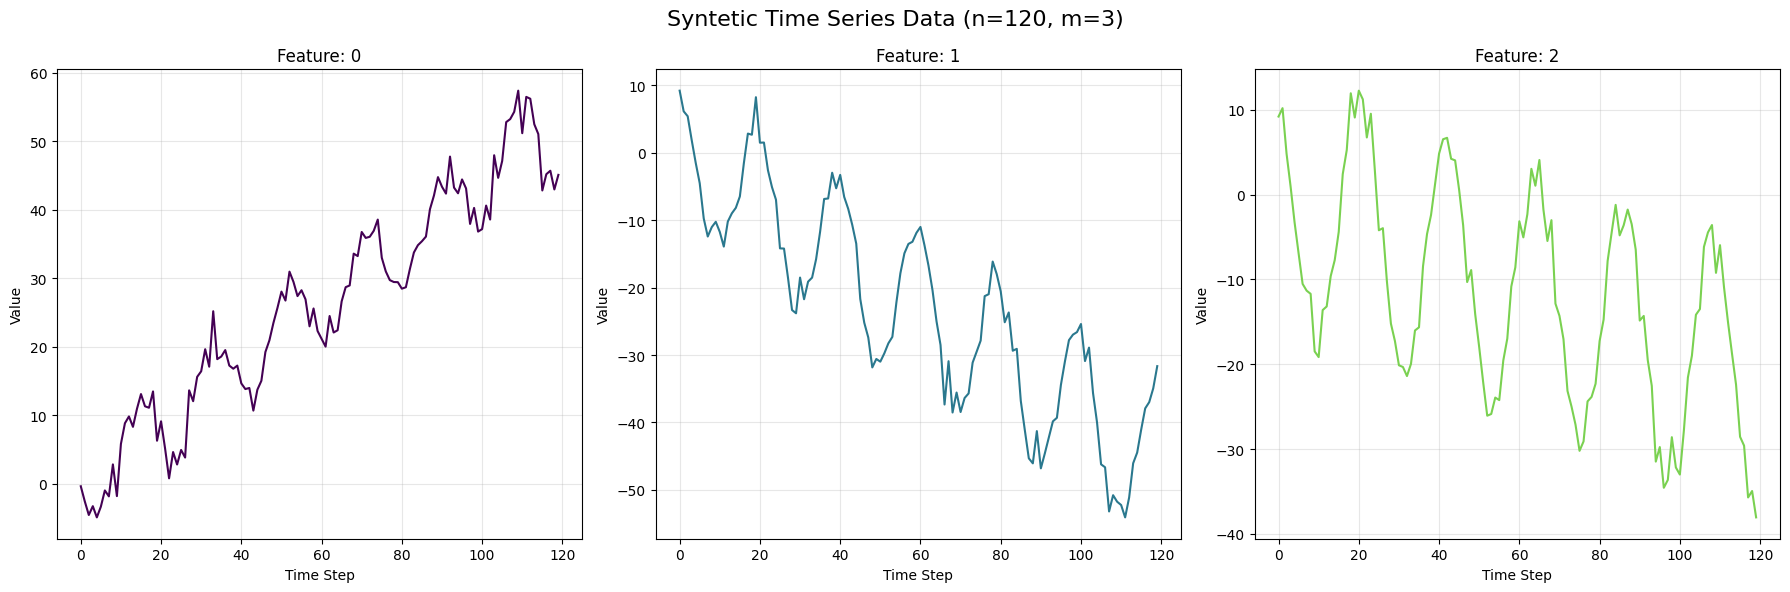

In [4]:
# adjust parameters
params = {
    "n":120, # dataset length
    "m":3, # feature amount
    "p":20, # prediction horizon
    "r":20 # memory
}

# create df
df = generate_synthetic_ts(n=params["n"], m=params["m"])

fig, axs = plt.subplots(1, 3, figsize=(6*params["m"], 6))
colors = plt.cm.viridis(np.linspace(0, 0.8, params["m"]))
for i, (ax, color) in enumerate(zip(axs, colors)):
    ax.plot(df[:,i], c=color)
    ax.set_title(f"Feature: {i}")
    ax.set_xlabel("Time Step")
    ax.set_ylabel("Value")
    ax.grid(True, alpha=0.3)
plt.suptitle(f"Syntetic Time Series Data (n={params["n"]}, m={params["m"]})", fontsize=16)
plt.tight_layout()
plt.show()

In [5]:
df[:10]

array([[ -0.40076698,   9.21937415,   9.20824757],
       [ -2.61235125,   6.15827249,  10.19690517],
       [ -4.59666805,   5.42653502,   4.82661057],
       [ -3.30915164,   1.89285126,   0.98401575],
       [ -4.94676271,  -1.48387999,  -3.27673767],
       [ -3.38277024,  -4.51335672,  -6.92429207],
       [ -1.01026125,  -9.73453652, -10.52607908],
       [ -1.87681011, -12.41664177, -11.31974266],
       [  2.79277085, -11.02566284, -11.69962896],
       [ -1.83866014, -10.23052391, -18.48028759]])

In [6]:
scaler = MinMaxScaler()
scaled_df = scaler.fit_transform(df)
scaled_df[:10]

array([[0.07291918, 1.        , 0.93936697],
       [0.03744468, 0.95164251, 0.95901642],
       [0.00561563, 0.94008295, 0.85228247],
       [0.02626779, 0.88425988, 0.77591137],
       [0.        , 0.83091626, 0.69122942],
       [0.02508692, 0.78305836, 0.61873472],
       [0.0631427 , 0.70057722, 0.54714965],
       [0.04924299, 0.6582069 , 0.53137568],
       [0.12414451, 0.68018077, 0.52382549],
       [0.04985493, 0.69274191, 0.38906073]])

In [7]:
# build model
model = MOLR(p=20,r=20)
losses = model.fit(scaled_df,inform=2,epsilon=0.005)

Model training started...
iter 0: loss: 8.798237245237612, old loss: 17.481693445231933
iter 1: loss: 5.054694840648672, old loss: 8.798237245237612
iter 2: loss: 3.4202708811114437, old loss: 5.054694840648672
iter 3: loss: 2.687048516993228, old loss: 3.4202708811114437
iter 4: loss: 2.3395767555078653, old loss: 2.687048516993228
iter 5: loss: 2.1578737815955225, old loss: 2.3395767555078653
iter 6: loss: 2.0480328714749425, old loss: 2.1578737815955225
iter 7: loss: 1.9699437741566324, old loss: 2.0480328714749425
iter 8: loss: 1.9064521730408615, old loss: 1.9699437741566324
iter 9: loss: 1.8502003126129085, old loss: 1.9064521730408615
iter 10: loss: 1.7980119818373297, old loss: 1.8502003126129085
iter 11: loss: 1.7484965920737972, old loss: 1.7980119818373297
iter 12: loss: 1.7010268087171445, old loss: 1.7484965920737972
iter 13: loss: 1.6553022649770575, old loss: 1.7010268087171445
iter 14: loss: 1.6111633524435893, old loss: 1.6553022649770575
iter 15: loss: 1.5685117186486

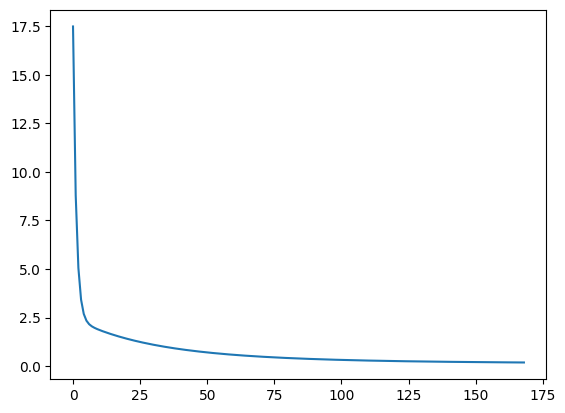

In [8]:
plt.plot(losses)

In [9]:
preds = model.predict(scaled_df)
preds_rescaled = scaler.inverse_transform(preds)
preds_rescaled

array([[ 50.34870404, -40.34994321, -31.40999527],
       [ 50.40386539, -39.7398089 , -30.08263182],
       [ 50.23342048, -39.22235908, -27.98232517],
       [ 50.75104776, -39.75101045, -25.77979424],
       [ 51.2381467 , -40.92892543, -22.98837306],
       [ 51.88569959, -42.78563985, -20.62757967],
       [ 53.09174893, -44.97366732, -18.23194225],
       [ 54.19401241, -47.55294108, -16.06686362],
       [ 55.74527211, -49.89142849, -14.59743613],
       [ 57.250974  , -52.19701314, -14.3896628 ],
       [ 58.17274057, -54.18088164, -14.44792013],
       [ 59.34302324, -55.66882852, -15.55955083],
       [ 60.39638506, -56.6746196 , -17.37898387],
       [ 60.75885253, -56.78677992, -19.85768613],
       [ 61.23215694, -56.50382068, -22.64083257],
       [ 60.48592998, -55.62869458, -25.69929187],
       [ 59.93844976, -54.2768192 , -28.63579404],
       [ 59.47636808, -52.62717662, -31.41977675],
       [ 58.76233207, -50.98592186, -33.47873566],
       [ 58.33564627, -49.04916

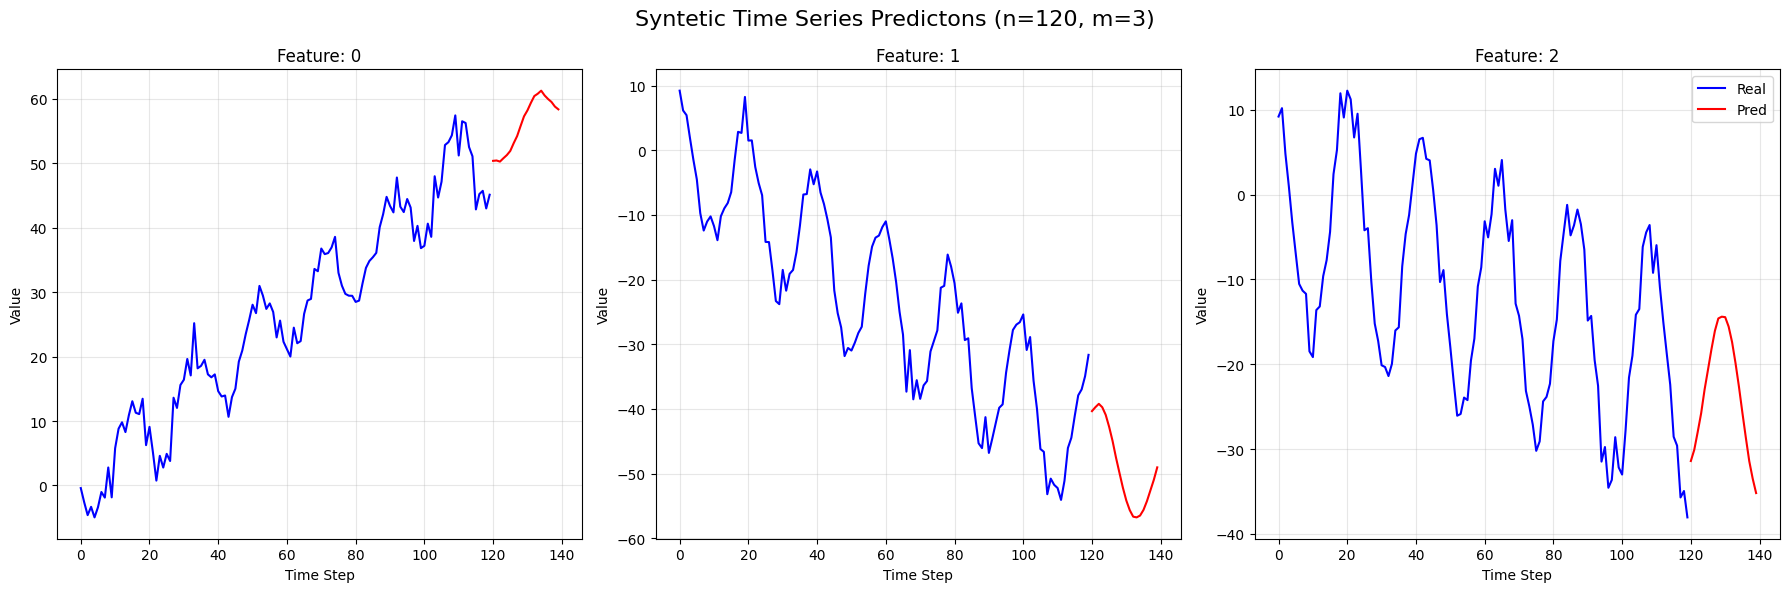

In [10]:
# plot predictions
fig, axs = plt.subplots(1, 3, figsize=(6*params["m"], 6))
for i, ax in enumerate(axs):
    ax.plot(df[:,i], c="blue", label="Real")
    preds_x_axis = range(len(df), len(df) + len(preds_rescaled))
    ax.plot(preds_x_axis, preds_rescaled[:,i], c="red", label="Pred")
    ax.set_title(f"Feature: {i}")
    ax.set_xlabel("Time Step")
    ax.set_ylabel("Value")
    ax.grid(True, alpha=0.3)
plt.suptitle(f"Syntetic Time Series Predictons (n={params["n"]}, m={params["m"]})", fontsize=16)
plt.tight_layout()
plt.legend()
plt.show()